In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not available. Please select GPU in Runtime settings.")


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [2]:
!pip install -q transformers scikit-learn pandas matplotlib seaborn


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import BertTokenizerFast
from transformers import BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [5]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving fake_or_real_news_cleaned.csv to fake_or_real_news_cleaned (1).csv
Uploaded files:
fake_or_real_news_cleaned (1).csv


In [6]:
import glob

csv_files = glob.glob("*.csv")

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
fake_or_real_news_cleaned.csv
fake_or_real_news_cleaned (1).csv


In [7]:
DATA_PATH = "fake_or_real_news_cleaned.csv"
df = pd.read_csv(DATA_PATH)

In [8]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

Dataset shape:
(6055, 4)

Column names:
['title', 'text', 'label', 'combined_text']

Missing values:
title            0
text             0
label            0
combined_text    0
dtype: int64

Label distribution:
label
FAKE    3066
REAL    2989
Name: count, dtype: int64


In [9]:
# Keep only the required columns
df = df[["title", "text", "label"]].copy()

# Convert title and text to strings
df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

# Convert labels to numeric
df["label"] = pd.to_numeric(df["label"], errors="coerce")

# Remove rows with invalid labels
df = df.dropna(subset=["label"])

# Convert labels to integer
df["label"] = df["label"].astype(int)

# Keep only labels 0 and 1
df = df[df["label"].isin([0, 1])]

# Combine title and article text
df["combined_text"] = (
    df["title"].str.strip()
    + " "
    + df["text"].str.strip()
)

# Remove empty articles
df = df[df["combined_text"].str.strip() != ""]

# Remove duplicate articles
df = df.drop_duplicates(subset=["combined_text"])

# Reset index
df = df.reset_index(drop=True)

print("Final dataset shape:", df.shape)

print("\nLabel distribution:")
print(df["label"].value_counts())

df.head()

Final dataset shape: (0, 4)

Label distribution:
Series([], Name: count, dtype: int64)


,title,text,label,combined_text


In [10]:
X = df["combined_text"].values
y = df["label"].values

print("Number of samples:", len(X))
print("Number of labels:", len(y))

Number of samples: 0
Number of labels: 0


In [11]:
print(df.shape)
print(df.columns.tolist())
print(df["label"].value_counts(dropna=False))

(0, 4)
['title', 'text', 'label', 'combined_text']
Series([], Name: count, dtype: int64)


In [12]:
print("X length:", len(X))
print("y length:", len(y))

print("DataFrame shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nLabel values:")
print(df["label"].value_counts(dropna=False))

X length: 0
y length: 0
DataFrame shape: (0, 4)

Columns:
['title', 'text', 'label', 'combined_text']

Label values:
Series([], Name: count, dtype: int64)


In [13]:
import pandas as pd

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nLabel values:")
print(df["label"].value_counts(dropna=False))

Dataset shape: (6055, 4)
Columns: ['title', 'text', 'label', 'combined_text']

Label values:
label
FAKE    3066
REAL    2989
Name: count, dtype: int64


In [14]:
df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

df["combined_text"] = (
    df["title"] + " " + df["text"]
)

# Check before removing anything
print("Rows before cleaning:", len(df))
print(df[["title", "text", "label"]].head())

Rows before cleaning: 6055
                                               title  \
0                       You Can Smell Hillary's Fear   
1  Watch The Exact Moment Paul Ryan Committed Pol...   
2        Kerry to go to Paris in gesture of sympathy   
3  Bernie supporters on Twitter erupt in anger ag...   
4   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


In [16]:
X = df["combined_text"].values
y = df["label"].values

print("X samples:", len(X))
print("y samples:", len(y))
print("Labels:")
print(pd.Series(y).value_counts(dropna=False))

X samples: 6055
y samples: 6055
Labels:
FAKE    3066
REAL    2989
Name: count, dtype: int64


In [17]:
# First split:
# 80% training
# 20% temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Second split:
# 10% validation
# 10% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 4844
Validation samples: 605
Testing samples: 606


In [18]:
total = len(X)

print(f"Training:   {len(X_train)} ({len(X_train)/total*100:.2f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/total*100:.2f}%)")
print(f"Testing:    {len(X_test)} ({len(X_test)/total*100:.2f}%)")

Training:   4844 (80.00%)
Validation: 605 (9.99%)
Testing:    606 (10.01%)


In [19]:
MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully.


In [20]:
class FakeNewsDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length=256):

        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [21]:
MAX_LENGTH = 256

train_dataset = FakeNewsDataset(
    X_train,
    y_train,
    tokenizer,
    MAX_LENGTH
)

val_dataset = FakeNewsDataset(
    X_val,
    y_val,
    tokenizer,
    MAX_LENGTH
)

test_dataset = FakeNewsDataset(
    X_test,
    y_test,
    tokenizer,
    MAX_LENGTH
)

print("Datasets created successfully.")

Datasets created successfully.


In [22]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [23]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model = model.to(device)

print("BERT model loaded successfully.")
print("Model is running on:", device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully.
Model is running on: cuda


In [24]:
EPOCHS = 5
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.1

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_training_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_training_steps),
    num_training_steps=total_training_steps
)

print("Training configuration:")
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Max length:", MAX_LENGTH)

Training configuration:
Epochs: 5
Learning rate: 3e-05
Batch size: 16
Max length: 256


In [25]:
def evaluate_model(model, data_loader):

    model.eval()

    total_loss = 0
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for batch in data_loader:

            input_ids = batch["input_ids"].to(
                device,
                non_blocking=True
            )

            attention_mask = batch["attention_mask"].to(
                device,
                non_blocking=True
            )

            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            probabilities = torch.softmax(logits, dim=1)

            predictions = torch.argmax(
                logits,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities[:, 1].cpu().numpy()
            )

    average_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="binary",
        zero_division=0
    )

    return (
        average_loss,
        accuracy,
        precision,
        recall,
        f1,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [26]:
# Convert text labels to numeric labels

df["label"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({
        "REAL": 0,
        "FAKE": 1
    })
)

# Remove invalid labels, if any
df = df.dropna(subset=["label"])

# Convert to integer
df["label"] = df["label"].astype(int)

print("Label distribution:")
print(df["label"].value_counts())

print("\nUnique labels:")
print(df["label"].unique())

Label distribution:
label
1    3066
0    2989
Name: count, dtype: int64

Unique labels:
[1 0]


In [ ]:
X = df["combined_text"].values
y = df["label"].values

print("X samples:", len(X))
print("y samples:", len(y))
print("Labels:", np.unique(y))

X samples: 6055
y samples: 6055
Labels: [0 1]


In [27]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 4844
Validation samples: 605
Testing samples: 606


In [28]:
train_dataset = FakeNewsDataset(
    X_train,
    y_train,
    tokenizer,
    MAX_LENGTH
)

val_dataset = FakeNewsDataset(
    X_val,
    y_val,
    tokenizer,
    MAX_LENGTH
)

test_dataset = FakeNewsDataset(
    X_test,
    y_test,
    tokenizer,
    MAX_LENGTH
)

print("Datasets recreated successfully.")

Datasets recreated successfully.


In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders recreated successfully.")

DataLoaders recreated successfully.


In [31]:
from tqdm.auto import tqdm

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

patience = 2
patience_counter = 0

BEST_MODEL_PATH = "/content/best_bert_fake_news_model"

os.makedirs(BEST_MODEL_PATH, exist_ok=True)

# Mixed precision only when CUDA is available
use_amp = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

for epoch in range(EPOCHS):

    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 60)

    # -------------------------
    # TRAINING
    # -------------------------

    model.train()

    total_train_loss = 0
    train_predictions = []
    train_labels = []

    progress_bar = tqdm(
        train_loader,
        desc=f"Training Epoch {epoch + 1}"
    )

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        attention_mask = batch["attention_mask"].to(
            device,
            non_blocking=True
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=use_amp
        ):

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)

        scaler.update()

        scheduler.step()

        total_train_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        train_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        train_labels.extend(
            labels.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=loss.item()
        )

    # -------------------------
    # TRAINING METRICS
    # -------------------------

    train_loss = (
        total_train_loss / len(train_loader)
    )

    train_accuracy = accuracy_score(
        train_labels,
        train_predictions
    )

    # -------------------------
    # VALIDATION
    # -------------------------

    (
        val_loss,
        val_accuracy,
        val_precision,
        val_recall,
        val_f1,
        _,
        _,
        _
    ) = evaluate_model(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print("\nTraining Results:")
    print(f"Train Loss:      {train_loss:.4f}")
    print(f"Train Accuracy:  {train_accuracy:.4f}")

    print("\nValidation Results:")
    print(f"Val Loss:        {val_loss:.4f}")
    print(f"Val Accuracy:    {val_accuracy:.4f}")
    print(f"Val Precision:   {val_precision:.4f}")
    print(f"Val Recall:      {val_recall:.4f}")
    print(f"Val F1:          {val_f1:.4f}")

    # -------------------------
    # SAVE BEST MODEL
    # -------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        model.save_pretrained(
            BEST_MODEL_PATH
        )

        tokenizer.save_pretrained(
            BEST_MODEL_PATH
        )

        print("\nBest model saved!")

        patience_counter = 0

    else:

        patience_counter += 1

        print(
            f"\nNo improvement. "
            f"Patience: {patience_counter}/{patience}"
        )

        if patience_counter >= patience:

            print("\nEarly stopping activated.")
            break

print("\nTraining completed.")
print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f}"
)


Epoch 1/5


Training Epoch 1:   0%|          | 0/303 [00:00<?, ?it/s]

ValueError: Caught ValueError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_677/2127998448.py", line 16, in __getitem__
    label = int(self.labels[idx])
            ^^^^^^^^^^^^^^^^^^^^^
ValueError: invalid literal for int() with base 10: 'FAKE'


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    BEST_MODEL_PATH
)

model = model.to(device)

print("Best model loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Best model loaded successfully.


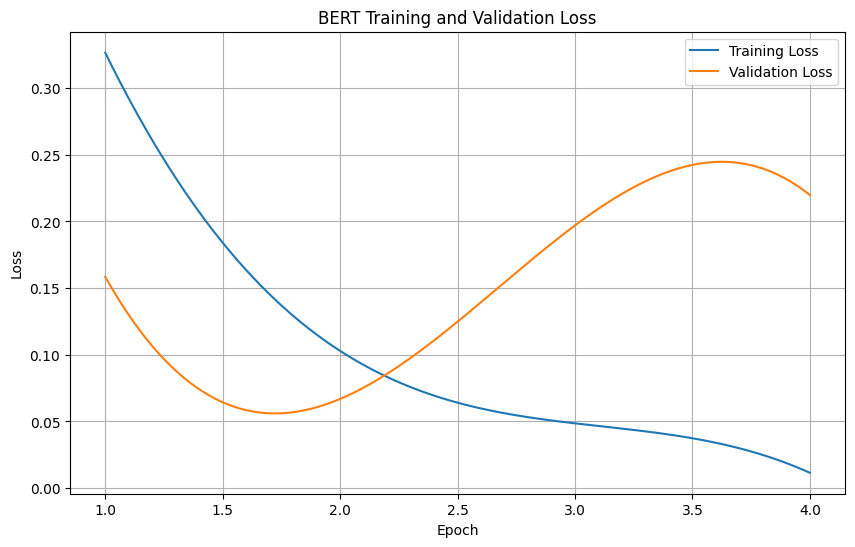

In [ ]:
 import numpy as np
from scipy.interpolate import make_interp_spline

epochs = np.arange(1, len(train_losses) + 1)
epochs_smooth = np.linspace(epochs.min(), epochs.max(), 300)

k_val = min(3, len(epochs) - 1)  # spline degree, adjusts automatically for small data

spline_train = make_interp_spline(epochs, train_losses, k=k_val)
train_smooth = spline_train(epochs_smooth)

spline_val = make_interp_spline(epochs, val_losses, k=k_val)
val_smooth = spline_val(epochs_smooth)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_smooth,
    train_smooth,
    label="Training Loss"
)

plt.plot(
    epochs_smooth,
    val_smooth,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

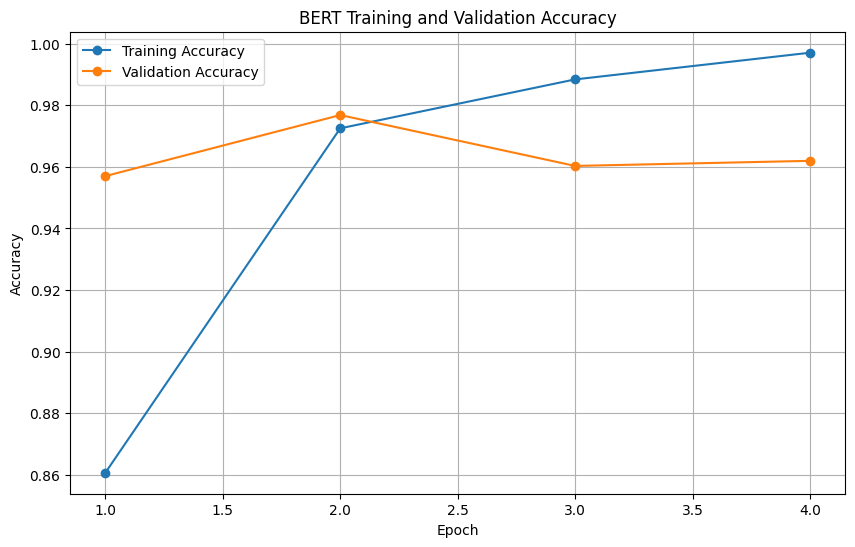

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_accuracies) + 1),
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(1, len(val_accuracies) + 1),
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BERT Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
(
    test_loss,
    test_accuracy,
    test_precision,
    test_recall,
    test_f1,
    test_labels,
    test_predictions,
    test_probabilities
) = evaluate_model(
    model,
    test_loader
)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Test Loss:       {test_loss:.4f}")
print(f"Test Accuracy:   {test_accuracy:.4f}")
print(f"Test Precision:  {test_precision:.4f}")
print(f"Test Recall:     {test_recall:.4f}")
print(f"Test F1 Score:   {test_f1:.4f}")

FINAL TEST RESULTS
Test Loss:       0.1226
Test Accuracy:   0.9653
Test Precision:  0.9767
Test Recall:     0.9544
Test F1 Score:   0.9654


In [ ]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["Real News", "Fake News"],
        digits=4
    )
)

              precision    recall  f1-score   support

   Real News     0.9542    0.9766    0.9653       299
   Fake News     0.9767    0.9544    0.9654       307

    accuracy                         0.9653       606
   macro avg     0.9655    0.9655    0.9653       606
weighted avg     0.9656    0.9653    0.9653       606



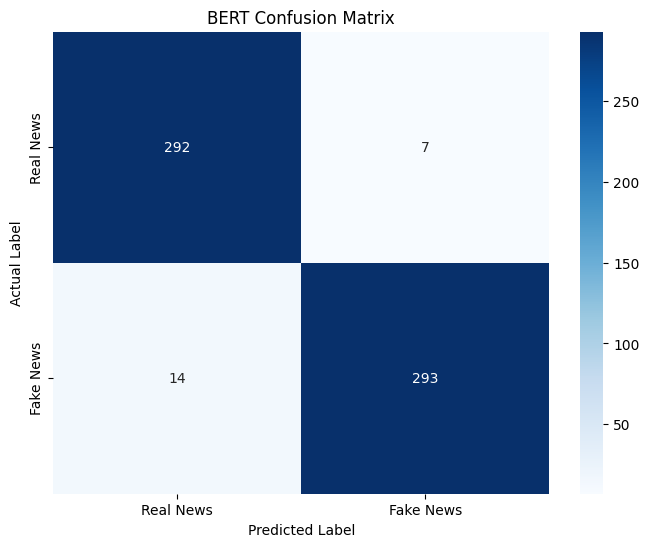

In [ ]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real News", "Fake News"],
    yticklabels=["Real News", "Fake News"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("BERT Confusion Matrix")

plt.show()

In [ ]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model.eval()

test_preds = []
test_probs = []
test_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        # probability of fake news class (label 1)
        probs = torch.softmax(logits, dim=1)[:, 1]

        # predicted class
        preds = torch.argmax(logits, dim=1)

        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())


# Metrics
test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)

# ROC-AUC
roc_auc = roc_auc_score(test_labels, test_probs)

print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.9653465346534653
Precision: 0.9766666666666667
Recall: 0.9543973941368078
F1 Score: 0.9654036243822076
ROC-AUC: 0.9942697155556525


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    test_labels,
    test_probs
)

In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        roc_auc
    ]
})

results["Percentage"] = (
    results["Score"] * 100
).round(2)

results

,Metric,Score,Percentage
0,Accuracy,0.965347,96.53
1,Precision,0.976667,97.67
2,Recall,0.954397,95.44
3,F1 Score,0.965404,96.54
4,ROC-AUC,0.994270,99.43


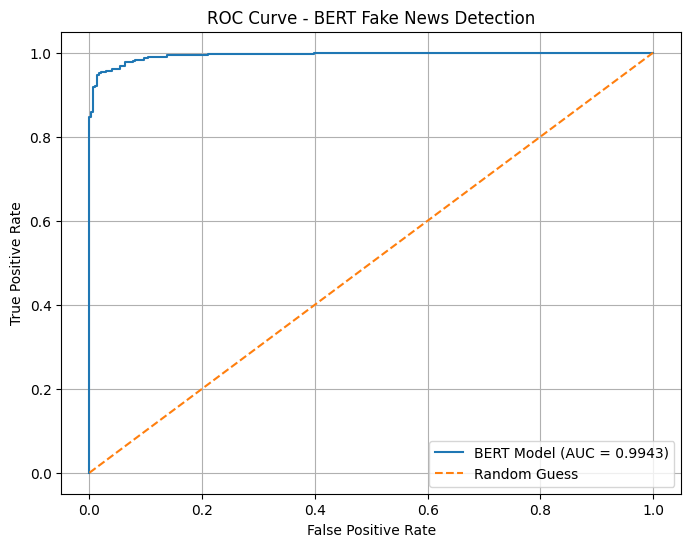

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(
    test_labels,
    test_probs
)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'BERT Model (AUC = {roc_auc:.4f})'
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BERT Fake News Detection")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [ ]:
FINAL_MODEL_PATH = "/content/final_bert_fake_news_model"

model.save_pretrained(
    FINAL_MODEL_PATH
)

tokenizer.save_pretrained(
    FINAL_MODEL_PATH
)

print("Final BERT model saved at:")
print(FINAL_MODEL_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final BERT model saved at:
/content/final_bert_fake_news_model


In [ ]:
def predict_fake_news(text):

    model.eval()

    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

        prediction = torch.argmax(
            probabilities,
            dim=1
        ).item()

    confidence = probabilities[0][prediction].item()

    if prediction == 0:
        label = "REAL NEWS"
    else:
        label = "FAKE NEWS"

    return label, confidence

In [ ]:
news = """
The government announced a new policy that will provide
additional support for university students.
"""

prediction, confidence = predict_fake_news(news)

print("Prediction:", prediction)
print(f"Confidence: {confidence * 100:.2f}%")

Prediction: REAL NEWS
Confidence: 97.59%
